# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** Phú Thành

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [2]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
california = fetch_california_housing(as_frame=True)
df = california.frame  # đã có sẵn cột target 'MedHouseVal'

print("Shape (số dòng, số cột):", df.shape)
print("\n===== df.info() =====")
df.info()

print("\n===== 5 dòng đầu =====")
display(df.head())

print("\n===== Kiểm tra missing values =====")
print(df.isnull().sum())
print("\nTổng số giá trị thiếu:", df.isnull().sum().sum())

Shape (số dòng, số cột): (20640, 9)

===== df.info() =====
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

===== 5 dòng đầu =====


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



===== Kiểm tra missing values =====
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Tổng số giá trị thiếu: 0


---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

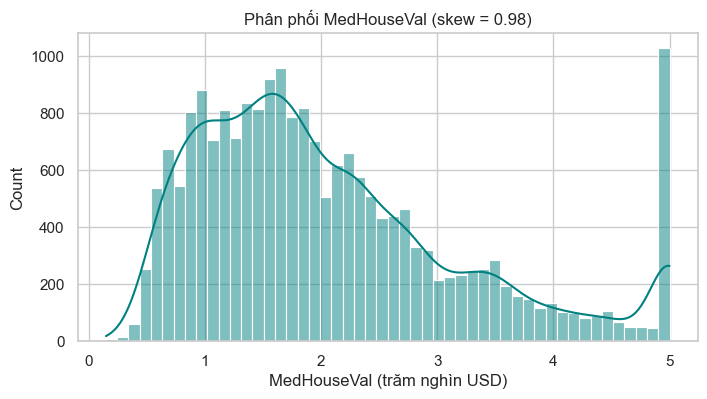

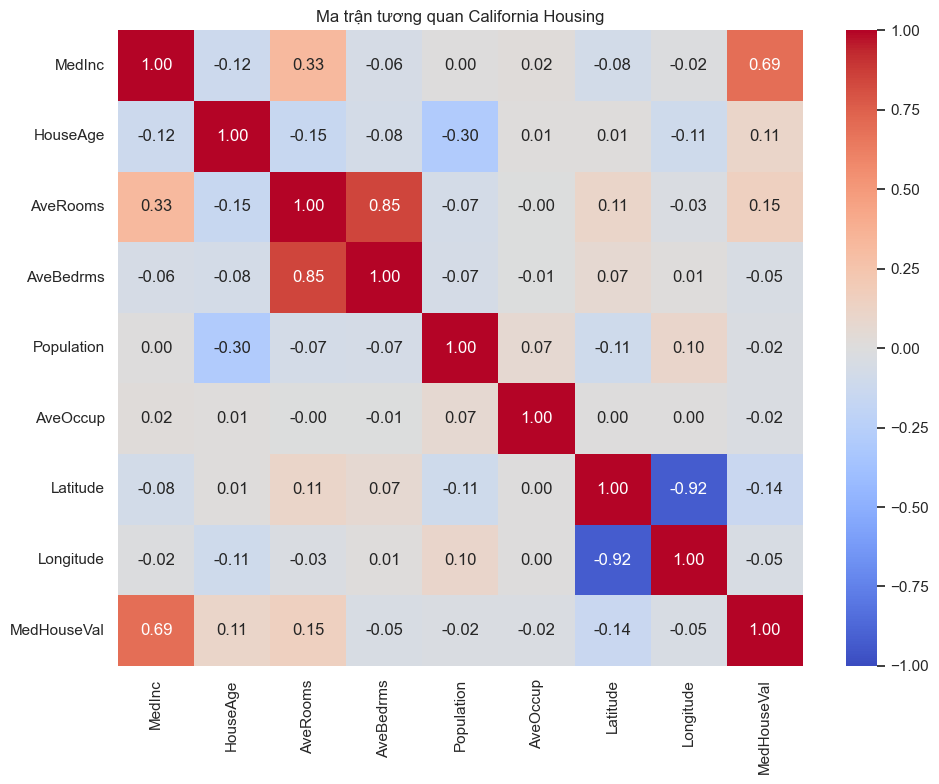

Tương quan với MedHouseVal (giảm dần):
MedInc        0.688
AveRooms      0.152
HouseAge      0.106
AveOccup     -0.024
Population   -0.025
Longitude    -0.046
AveBedrms    -0.047
Latitude     -0.144
Name: MedHouseVal, dtype: float64


In [3]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="MedHouseVal", kde=True, bins=50, color="teal")
plt.title(f"Phân phối MedHouseVal (skew = {df['MedHouseVal'].skew():.2f})")
plt.xlabel("MedHouseVal (trăm nghìn USD)")
plt.show()

# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan California Housing")
plt.tight_layout()
plt.show()

# In tương quan của các đặc trưng với target để trả lời có căn cứ
print("Tương quan với MedHouseVal (giảm dần):")
print(df.corr()["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False).round(3))

**Trả lời 2:**

- **Hình dáng phân phối `MedHouseVal`:** phân phối **lệch phải (right-skewed)**, phần lớn giá nhà tập trung ở khoảng 1–2.5 (tức 100k–250k USD). Đáng chú ý là có một **cột dồn nhân tạo ở giá trị ~5.0** — đây là do dữ liệu bị **cắt trần (capped)** ở 5.0: mọi căn nhà đắt hơn 500k USD đều bị gán về 5.0, tạo ra một đỉnh giả ở cạnh phải.

- **Đặc trưng tương quan dương mạnh nhất với giá nhà là `MedInc`** (thu nhập trung bình của khu vực), với hệ số tương quan ≈ **+0.69** — vượt trội hẳn so với các đặc trưng còn lại. Điều này hợp lý: khu vực có thu nhập càng cao thì giá nhà càng cao.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [4]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

# Chia 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale: fit CHỈ trên train để tránh data leakage, rồi transform cả hai tập
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # học mean/std trên train
X_test_scaled  = scaler.transform(X_test)        # dùng đúng tham số đó cho test

print("X_train:", X_train_scaled.shape, "| X_test:", X_test_scaled.shape)
print("Kiểm tra sau scale (train): mean ≈ 0, std ≈ 1")
print("  mean:", np.round(X_train_scaled.mean(axis=0), 3))
print("  std :", np.round(X_train_scaled.std(axis=0), 3))

X_train: (16512, 8) | X_test: (4128, 8)
Kiểm tra sau scale (train): mean ≈ 0, std ≈ 1
  mean: [-0. -0.  0. -0.  0.  0.  0.  0.]
  std : [1. 1. 1. 1. 1. 1. 1. 1.]


---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

In [5]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
def evaluate_model(model, X_te, y_te, name=""):
    """Tính RMSE và R2 trên tập test, in kết quả và trả về (rmse, r2)."""
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    print(f"{name:20s} - RMSE: {rmse:.4f}, R2: {r2:.4f}")
    return rmse, r2

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")

Linear Regression - RMSE: 0.7456, R2: 0.5758


---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [6]:
# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)

# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

# So sánh cả 3 mô hình (dùng lại hàm evaluate_model ở Task 4)
print("===== So sánh RMSE / R2 trên tập test =====")
evaluate_model(lr_model,    X_test_scaled, y_test, "Linear Regression")
evaluate_model(ridge_model, X_test_scaled, y_test, "Ridge (alpha=10)")
evaluate_model(lasso_model, X_test_scaled, y_test, "Lasso (alpha=0.1)")

===== So sánh RMSE / R2 trên tập test =====
Linear Regression    - RMSE: 0.7456, R2: 0.5758
Ridge (alpha=10)     - RMSE: 0.7453, R2: 0.5761
Lasso (alpha=0.1)    - RMSE: 0.8244, R2: 0.4814


(np.float64(0.8243961598848472), 0.48136113250290735)

---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

Bảng hệ số hồi quy của 3 mô hình:


,Linear,Ridge,Lasso
MedInc,0.8544,0.8538,0.7106
HouseAge,0.1225,0.1233,0.1065
AveRooms,-0.2944,-0.2924,-0.0000
AveBedrms,0.3393,0.3367,0.0000
Population,-0.0023,-0.0021,-0.0000
AveOccup,-0.0408,-0.0409,-0.0000
Latitude,-0.8969,-0.8894,-0.0115
Longitude,-0.8698,-0.8622,-0.0000


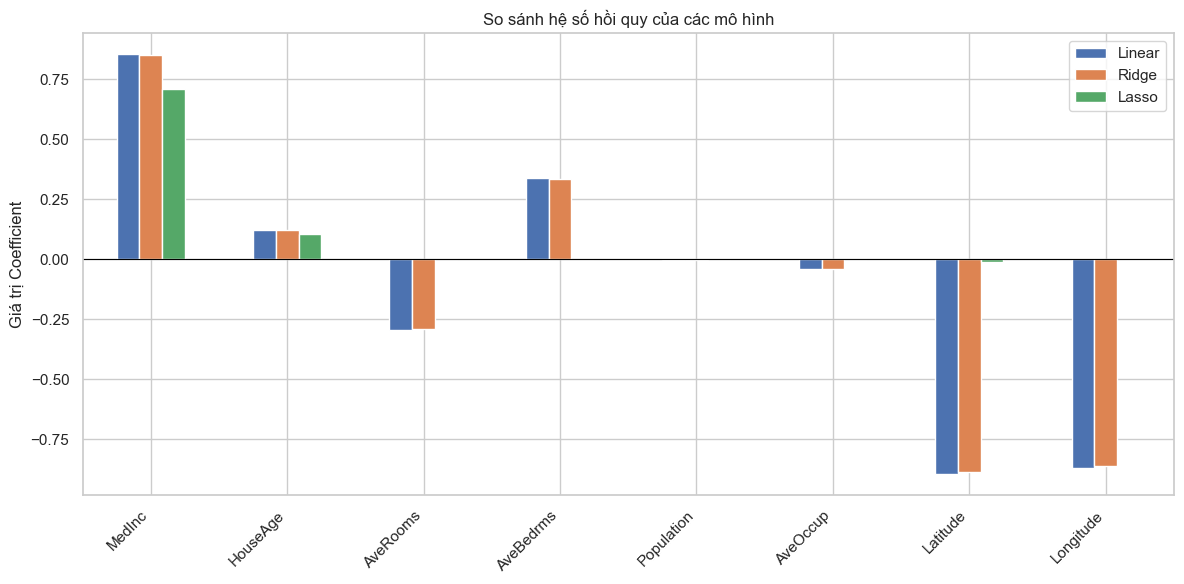

Số đặc trưng bị Lasso ép hệ số về đúng 0: 5
Các đặc trưng bị loại: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']


In [7]:
# TODO 6: Trực quan hóa Coefficients
features = california.feature_names
coef_df = pd.DataFrame({
    "Linear": lr_model.coef_,
    "Ridge":  ridge_model.coef_,
    "Lasso":  lasso_model.coef_,
}, index=features)

print("Bảng hệ số hồi quy của 3 mô hình:")
display(coef_df.round(4))

# Vẽ biểu đồ so sánh các thanh cạnh nhau
coef_df.plot(kind="bar", figsize=(12, 6))
plt.title("So sánh hệ số hồi quy của các mô hình")
plt.ylabel("Giá trị Coefficient")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Đếm số hệ số bị Lasso ép về 0
n_zero = int((lasso_model.coef_ == 0).sum())
print(f"Số đặc trưng bị Lasso ép hệ số về đúng 0: {n_zero}")
print("Các đặc trưng bị loại:", [f for f, c in zip(features, lasso_model.coef_) if c == 0])

**Trả lời 6:**

Quan sát hệ số của **Lasso (L1)**, điều đặc biệt là một số đặc trưng bị **ép hệ số về đúng bằng 0** (ví dụ `AveBedrms`, và với `alpha=0.1` các đặc trưng yếu khác cũng bị thu nhỏ mạnh về 0), trong khi Linear và Ridge chỉ *thu nhỏ* hệ số chứ không bao giờ đưa về đúng 0.

- **Ridge (L2)** phạt theo bình phương hệ số → **co (shrinkage)** đều các hệ số về gần 0 nhưng giữ lại tất cả đặc trưng.
- **Lasso (L1)** phạt theo trị tuyệt đối → tạo ra nghiệm **thưa (sparse)**, đẩy hẳn hệ số của các đặc trưng ít quan trọng về 0.

Tính chất "ép về 0" này của Lasso được ứng dụng để **chọn lọc đặc trưng (Feature Selection) tự động**: những đặc trưng có hệ số = 0 coi như bị loại khỏi mô hình, giúp mô hình **gọn hơn, dễ giải thích hơn** và giảm nguy cơ overfit khi có nhiều đặc trưng dư thừa/nhiễu.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [8]:
# TODO Bonus: GridSearchCV cho Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(
    Ridge(), param_grid, cv=5, scoring="neg_root_mean_squared_error"
)
grid_search.fit(X_train_scaled, y_train)

print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
print(f"RMSE trung bình (CV) tốt nhất: {-grid_search.best_score_:.4f}")

# Đánh giá lại mô hình Ridge tốt nhất trên tập test
best_ridge = grid_search.best_estimator_
evaluate_model(best_ridge, X_test_scaled, y_test, "Ridge (best alpha)")

Alpha tốt nhất cho Ridge: {'alpha': 0.1}


RMSE trung bình (CV) tốt nhất: 0.7205
Ridge (best alpha)   - RMSE: 0.7456, R2: 0.5758


(np.float64(0.7455789118982765), 0.5757905180002314)

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
